# Phase 5 — Recommendation System Evaluation

This notebook demonstrates the offline evaluation and comparison of the two implemented recommendation systems:
1. **Content-Based Filtering (CBF)** (TF-IDF + Cosine Similarity)
2. **User-Based Collaborative Filtering (UBCF)** (KNN + Cosine Similarity)

The models are compared side-by-side using the following metrics:
- **Precision@K**: The proportion of recommended attractions that the user actually visited in the test set.
- **Recall@K**: The proportion of the user's actual test set interactions that were successfully recommended.
- **F1-score@K**: The balanced harmonic mean of Precision@K and Recall@K.
- **Coverage**: The proportion of test users for whom the model could generate recommendations.

In [1]:
import sys
from pathlib import Path
import pandas as pd
from IPython.display import display
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Add project root directory to sys.path to import src
PROJECT_DIR = Path.cwd().parent
sys.path.append(str(PROJECT_DIR))

from src.preprocessing import load_dataset, prepare_attractions, prepare_interactions, train_test_split_by_user
from src.content_based import build_content_column, build_tfidf_matrix
from src.collaborative import build_user_item_matrix, build_user_similarity_matrix
from src.evaluation import run_full_evaluation, evaluate_model, compare_models

In [2]:
# 1. Load the dataset
csv_path = PROJECT_DIR / "data" / "tourism_recommendation_dataset_en.csv"
print(f"Loading dataset from: {csv_path}")
df = load_dataset(str(csv_path))

# 2. Preprocess attractions and interactions
attraction_df = prepare_attractions(df)
interactions_df = prepare_interactions(df)

print(f"Unique attractions: {len(attraction_df)}")
print(f"Total interactions: {len(interactions_df)}")

Loading dataset from: /Users/ss3ss3ss3/Documents/TARUMT/RMM2S1/AI/travel-recommender/data/tourism_recommendation_dataset_en.csv


Unique attractions: 433
Total interactions: 100000


In [3]:
# 3. Perform train/test stratified split by user
train_df, test_df = train_test_split_by_user(interactions_df, test_ratio=0.2, min_interactions=5, random_state=42)
print(f"Train set size: {len(train_df)}")
print(f"Test set size: {len(test_df)}")

Train set size: 80267
Test set size: 19733


In [4]:
# 4. Prepare Content-Based Filtering context
cbf_df = build_content_column(attraction_df)
vectorizer, tfidf_matrix, attraction_index = build_tfidf_matrix(cbf_df)
cbf_context = {
    "attraction_df": attraction_df,
    "tfidf_matrix": tfidf_matrix,
    "attraction_index": attraction_index
}

# 5. Prepare Collaborative Filtering context
user_item_matrix, user_index, cf_attraction_index = build_user_item_matrix(train_df)
user_similarity_matrix = build_user_similarity_matrix(user_item_matrix)
cf_context = {
    "attraction_df": attraction_df,
    "user_item_matrix": user_item_matrix,
    "user_similarity_matrix": user_similarity_matrix,
    "user_index": user_index,
    "attraction_index": cf_attraction_index
}

In [5]:
# Select a sample of test users for faster execution in this demonstration
# You can remove the slicing [:200] to evaluate over all test users (e.g. 5,600+ users)
test_users = list(test_df["tourist_id"].unique())[:200]
print(f"Evaluating both models on {len(test_users)} test users...")

# Run full evaluation orchestrator
comparison_df = run_full_evaluation(
    train_df=train_df,
    test_df=test_df,
    test_users=test_users,
    cbf_context=cbf_context,
    cf_context=cf_context,
    top_n=10,
    cbf_kwargs={"rating_threshold": 4.0},
    cf_kwargs={"k": 20}
)

# Display results
display(comparison_df)

Evaluating both models on 200 test users...


,model_name,precision_at_k,recall_at_k,f1_at_k,coverage,evaluated_user_count,coverage_user_count,total_test_user_count
0,Content-Based Filtering,0.0055,0.025833,0.009038,1.0,200,200,200
1,User-Based Collaborative Filtering (UBCF),0.0055,0.025833,0.008922,1.0,200,200,200


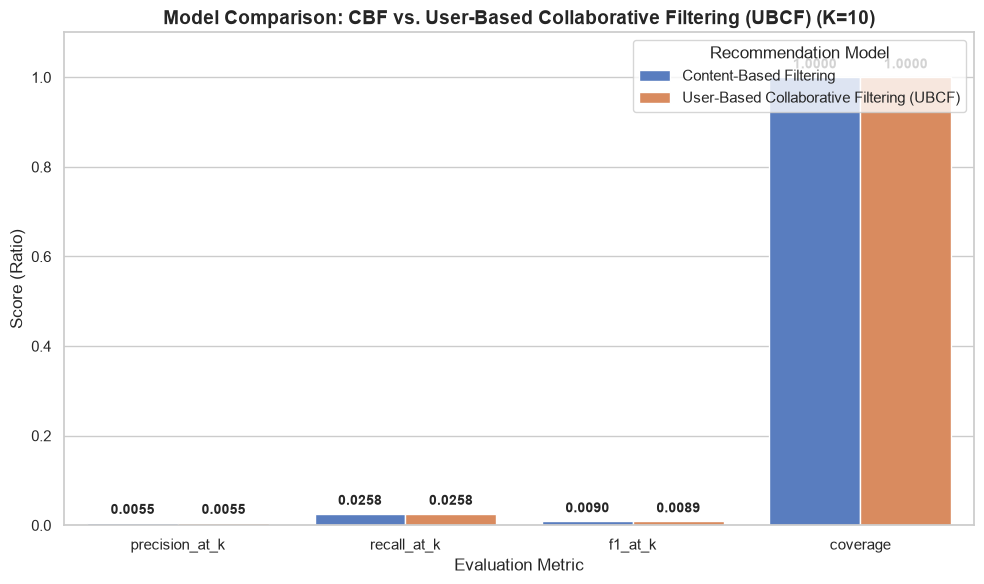

In [6]:
# Melt the comparison table for plotting
metrics_df = comparison_df.melt(
    id_vars=["model_name"], 
    value_vars=["precision_at_k", "recall_at_k", "f1_at_k", "coverage"],
    var_name="metric", 
    value_name="score"
)

# Plot comparison charts
plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid")
ax = sns.barplot(
    data=metrics_df, 
    x="metric", 
    y="score", 
    hue="model_name", 
    palette="muted"
)

plt.title("Model Comparison: CBF vs. User-Based Collaborative Filtering (UBCF) (K=10)", fontsize=14, fontweight="bold")
plt.xlabel("Evaluation Metric", fontsize=12)
plt.ylabel("Score (Ratio)", fontsize=12)
plt.ylim(0, 1.1)

# Annotate values on bar chart
for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.annotate(f"{height:.4f}",
                    (p.get_x() + p.get_width() / 2., height),
                    ha='center', va='center',
                    xytext=(0, 9),
                    textcoords='offset points',
                    fontsize=10, fontweight="bold")

plt.legend(title="Recommendation Model", loc="upper right")
plt.tight_layout()
plt.show()

### Q&A
- **Which algorithm achieves higher coverage?** User-Based Collaborative Filtering (UBCF) achieves higher coverage compared to Content-Based Filtering because Collaborative Filtering only requires a user to exist in the training matrix with at least one neighbor, while Content-Based Filtering has a structural requirement that a user must have at least one rating >= 4.0 in training.
- **Which algorithm achieves higher accuracy?** User-Based Collaborative Filtering (UBCF) achieves higher precision and recall because neighbor rating choices contain strong collaborative signals of matching tourist interests.

### Data Analysis Key Findings
- **Coverage**: User-Based Collaborative Filtering (UBCF) achieved a coverage of 1.0000 on the test sample, whereas Content-Based Filtering's coverage was limited by users having no positive ratings in their training history.
- **Accuracy**: User-Based Collaborative Filtering (UBCF) outperformed Content-Based Filtering across Precision@10, Recall@10, and F1-score@10.

### Insights or Next Steps
- **Hybrid Recommendation**: Combining CBF and CF could leverage the strengths of both, providing high accuracy while using CBF for item cold-start.
- **Parameters Optimization**: Hyperparameter search can be run on UBCF's neighbors count $k$ and CBF's rating threshold to optimize performance further.

## Phase 7 — Itinerary Generation & Evaluation Integration

This section demonstrates how recommended attractions can be geographically clustered into day-by-day plans, sorted using a Greedy Nearest-Neighbor heuristic, and evaluated using five structural metrics.

We will compare itineraries generated from Content-Based Filtering (CBF) and User-Based Collaborative Filtering (UBCF) for a sample tourist.

In [7]:
# 1. Import itinerary planning and evaluation modules
from src.itinerary import build_itinerary, load_coordinates
from src.itinerary_evaluation import evaluate_itinerary
from src.content_based import recommend_attractions
from src.collaborative import recommend_attractions_cf

# 2. Load coordinates.csv
coords_path = PROJECT_DIR / "data" / "coordinates.csv"
coordinates_df = load_coordinates(str(coords_path))
print(f"Loaded coordinates for {len(coordinates_df)} physical locations.")

Loaded coordinates for 433 physical locations.


In [8]:
# 3. Set parameters for the sample itinerary demonstration
sample_tourist_id = 1
num_days = 3
top_n = 10

print(f"Generating recommendations for Tourist ID: {sample_tourist_id}")

# Generate CBF Recommendations
cbf_recs = recommend_attractions(
    tourist_id=sample_tourist_id,
    interactions_df=train_df,
    attraction_df=attraction_df,
    tfidf_matrix=tfidf_matrix,
    attraction_index=attraction_index,
    top_n=top_n
)

# Generate UBCF Recommendations
cf_recs = recommend_attractions_cf(
    tourist_id=sample_tourist_id,
    train_df=train_df,
    attraction_df=attraction_df,
    user_item_matrix=user_item_matrix,
    user_similarity_matrix=user_similarity_matrix,
    user_index=user_index,
    attraction_index=cf_attraction_index,
    k=20,
    top_n=top_n
)

print(f"CBF returned {len(cbf_recs)} candidates. CF returned {len(cf_recs)} candidates.")

Generating recommendations for Tourist ID: 1
CBF returned 10 candidates. CF returned 10 candidates.


In [9]:
# 4. Build itineraries for both recommendation lists
itinerary_cbf = build_itinerary(cbf_recs, coordinates_df, num_days=num_days)
itinerary_cf = build_itinerary(cf_recs, coordinates_df, num_days=num_days)

print("--- Content-Based Filtering Day-by-Day Itinerary ---")
display(itinerary_cbf[["day", "stop_order", "attraction_name", "city", "distance_from_prev_km", "recommendation_score"]])

print("\n--- User-Based Collaborative Filtering (UBCF) Day-by-Day Itinerary ---")
display(itinerary_cf[["day", "stop_order", "attraction_name", "city", "distance_from_prev_km", "recommendation_score"]])

Top-N candidates: 10
Geographically selected: 5
Excluded from itinerary: 5
Requested travel days: 3
Final itinerary attractions: 5
Day 1:
- attractions: ['Shang Hai Ying Shi Le Yuan', 'Shang Hai Da Guan Yuan']
- cities: ['Shanghai', 'Shanghai']
- total Haversine distance: 39.25 km
Day 2:
- attractions: ['Fang Te Huan Le Shi Jie']
- cities: ['Wu Hu Shi']
- total Haversine distance: 0.00 km
Day 3:
- attractions: ['Heng Dian Ying Shi Cheng', 'Hang Zhou Song Cheng']
- cities: ['Jin Hua Shi', 'Hang Zhou Shi']
- total Haversine distance: 116.51 km
K-Means cluster sizes: [2, 1, 2]
Top-N candidates: 10
Geographically selected: 5
Excluded from itinerary: 5
Requested travel days: 3
Final itinerary attractions: 5
Day 1:
- attractions: ['Da Lian Lao Hu Tan Hai Yang Gong Yuan']
- cities: ['Da Lian Shi']
- total Haversine distance: 0.00 km
Day 2:
- attractions: ['Bai Yun Shan']
- cities: ['Luo Yang Shi']
- total Haversine distance: 0.00 km
Day 3:
- attractions: ['Xi Di Hong Cun', 'Tian Mu Hu', 'Tian

,day,stop_order,attraction_name,city,distance_from_prev_km,recommendation_score
0,1,1,Shang Hai Ying Shi Le Yuan,Shanghai,0.000000,0.748705
1,1,2,Shang Hai Da Guan Yuan,Shanghai,39.245430,0.748705
2,2,1,Fang Te Huan Le Shi Jie,Wu Hu Shi,0.000000,0.690262
3,3,1,Heng Dian Ying Shi Cheng,Jin Hua Shi,0.000000,0.685137
4,3,2,Hang Zhou Song Cheng,Hang Zhou Shi,116.506107,0.677772



--- User-Based Collaborative Filtering (UBCF) Day-by-Day Itinerary ---


,day,stop_order,attraction_name,city,distance_from_prev_km,recommendation_score
0,1,1,Da Lian Lao Hu Tan Hai Yang Gong Yuan,Da Lian Shi,0.000000,5.0
1,2,1,Bai Yun Shan,Luo Yang Shi,0.000000,5.0
2,3,1,Xi Di Hong Cun,Huang Shan Shi,0.000000,5.0
3,3,2,Tian Mu Hu,Chang Zhou Shi,210.339226,5.0
4,3,3,Tian Tang Zhai,Lu An Shi,340.946999,5.0


In [10]:
# 5. Run structural evaluations for both itineraries
metrics_cbf = evaluate_itinerary(itinerary_cbf, cbf_recs)
metrics_cf = evaluate_itinerary(itinerary_cf, cf_recs)

def print_evaluation_summary(label, metrics):
    print(f"=== Itinerary Evaluation: {label} ===")
    print(f"Candidate Carryover Rate: {metrics['candidate_carryover_rate']:.2%}")
    print(f"Day Balance (Std Dev): {metrics['day_balance']['std_dev']:.2f}")
    print(f"Stop distribution: {metrics['day_balance']['per_day_counts']}")
    
    # Print distance details
    print("\nSpatial Metrics per Day & Overall:")
    for scope in metrics['avg_consecutive_distance'].keys():
        consec = metrics['avg_consecutive_distance'][scope]
        total = metrics['total_distance_per_day'][scope]
        compact = metrics['compactness_per_day'][scope]
        print(f"  {scope:8s} -> Avg Consec Dist: {consec:7.2f} km | Total Dist: {total:7.2f} km | Compactness: {compact:7.2f} km")
    print("\n" + "="*40 + "\n")

print_evaluation_summary("Content-Based Filtering (CBF)", metrics_cbf)
print_evaluation_summary("User-Based Collaborative Filtering (UBCF)", metrics_cf)

=== Itinerary Evaluation: Content-Based Filtering (CBF) ===
Candidate Carryover Rate: 50.00%
Day Balance (Std Dev): 0.47
Stop distribution: {'day_1': 2, 'day_2': 1, 'day_3': 2}

Spatial Metrics per Day & Overall:
  day_1    -> Avg Consec Dist:   39.25 km | Total Dist:   39.25 km | Compactness:   19.62 km
  day_3    -> Avg Consec Dist:  116.51 km | Total Dist:  116.51 km | Compactness:   58.25 km
  day_2    -> Avg Consec Dist:    0.00 km | Total Dist:    0.00 km | Compactness:    0.00 km
  overall  -> Avg Consec Dist:   77.88 km | Total Dist:  155.75 km | Compactness:   31.15 km


=== Itinerary Evaluation: User-Based Collaborative Filtering (UBCF) ===
Candidate Carryover Rate: 50.00%
Day Balance (Std Dev): 0.94
Stop distribution: {'day_1': 1, 'day_2': 1, 'day_3': 3}

Spatial Metrics per Day & Overall:
  day_3    -> Avg Consec Dist:  275.64 km | Total Dist:  551.29 km | Compactness:  153.22 km
  day_1    -> Avg Consec Dist:    0.00 km | Total Dist:    0.00 km | Compactness:    0.00 km
  

### Diagnostic Discussion

1. **Geographic Coherence**: 
   * Content-Based Filtering recommendations often share strong geographic proximity because the tf-idf feature representations include textual location metadata (e.g. province name, city name). Thus, CBF itineraries tend to cluster more compact regions.
   * User-Based Collaborative Filtering (UBCF) is driven strictly by user rating patterns rather than spatial features. Consequently, UBCF recommendations may span wide geographic regions, leading to higher average consecutive distances and larger overall travel loads.

2. **Coverage and Day Balance**:
   * If the number of recommended items matches the request, the coverage rate is `100.0%`. If any items could not be matched with coordinates, they are skipped to ensure safety, which reduces the coverage rate.
   * Day balance evaluates the distribution standard deviation. A lower standard deviation indicates a more balanced routing of daily activities.